In [1]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload

from PyCoFie import *

In [ ]:
import sunpy.map
import astropy.units as u
import scipy.interpolate as interpolate

# Initialize: downscale HMI boundary condition

In [3]:
magfile = 'hmi.synoptic_mr_polfil_720s.2193.Mr_polfil.fits'
#magfile = '/home/chingamfong/Downloads/G4S_Pres/HMI_synop/hmi.synoptic_mr_polfil_720s.2149.Mr_polfil.fits'
hmi_map = sunpy.map.Map(magfile)
Np = int(360)
Nt = int(180)
#hmi_map = hmi_map.resample([Np, Nt] * u.pix)

sp, st = int(hmi_map.data.shape[1]/Np), int(hmi_map.data.shape[0]/Nt)
hmi_map_superpix = hmi_map.superpixel([sp, st] * u.pix, func = np.mean)


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


For frame 'heliographic_stonyhurst' the following metadata is missing: dsun_obs,hglt_obs,hgln_obs
For frame 'heliographic_carrington' the following metadata is missing: crlt_obs,dsun_obs,crln_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: dsun_obs,hglt_obs,hgln_obs
For frame 'heliographic_carrington' the following metadata is missing: crlt_obs,dsun_obs,crln_obs
 [sunpy.map.mapbase]


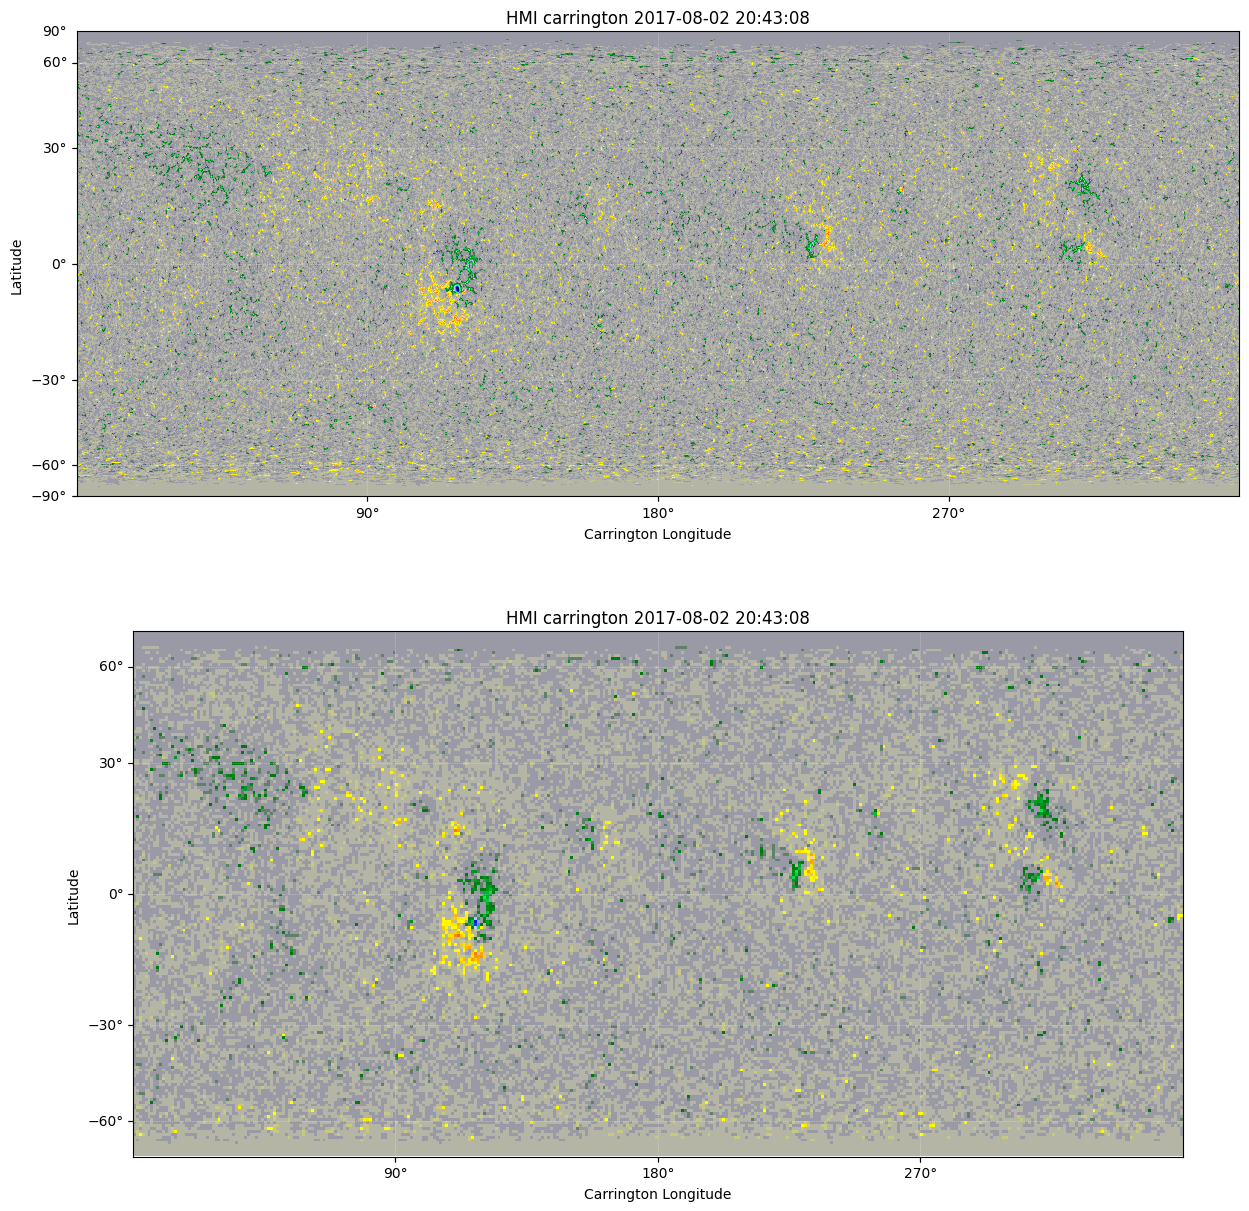

In [4]:
plt.figure(figsize = [15, 15])
ax1 = plt.subplot(2, 1, 1, projection = hmi_map)
ax2 = plt.subplot(2, 1, 2, projection = hmi_map_superpix)
hmi_map.plot(axes = ax1)
hmi_map_superpix.plot(axes = ax2)
plt.show()

# Calculate spherical harmonics, and PFSS / CSSS B_(r, t, p) on a set grid

In [ ]:
Br_in = hmi_map_superpix.data
print(np.shape(Br_in)[0], np.shape(Br_in)[1])
gh_result = get_gh(Br_in, N = 60)

180 360


In [6]:
Nr = 51
Rs, Rc, a = 2.5, 1.7, 1

nums, dlogr = np.arange(Nr), np.log(Rs)/(Nr-1)
r = np.exp(nums*dlogr)

In [7]:
Brp, Btp, Bpp = rec_Brtp_PFSS(gh_result, r, N = 60, Rs = Rs, 
                              Np = Np+1, Nt = Nt+1, 
                                  eqtheta = False, gridcenter = False)

In [8]:
Brc, Btc, Bpc = rec_Brtp_CSSS_full(gh_result, r, 
                                   Rs = Rs, Rc = Rc, a = a,
                                   N = 60, Ncusp = 9,
                                   Np = Np+1, Nt = Nt+1,
                                      gridcenter = False)

# Make vector grid, Field line tracing

In [9]:
step_size = 0.01

nsteps = int(2*Rs/step_size)
print(nsteps)
tracer = StreamTracer(nsteps, step_size)
    
costheta, phi, costheta_l, sintheta_l, phi_l = get_ct_p_grids(Nt+1, Np+1, eqtheta = False, gridcenter = False)


t_coord = np.arccos(costheta_l)
p_coord = phi_l


vector_grid_full = build_sph_vector_grid(Brc, Btc, Bpc, 
                                      r, t_coord, p_coord,
                                      fliptheta = True)

500


In [34]:
nsteps = 8
rval = 1.2

Nlines_v, Nlines_h = nsteps + 1, 2*nsteps + 1

lon_1d = np.linspace(0, 360, Nlines_h)
lat_1d = np.linspace(-90, 90, Nlines_v + 2)[1:-1]

lon, lat = np.meshgrid(lon_1d, lat_1d, indexing='ij')
lon, lat = lon*u.deg, lat*u.deg
lon, lat = lon.ravel(), lat.ravel()

In [35]:
seeds_full = np.ones((Nlines_h*Nlines_v, 3))
seeds_full[:, 0], seeds_full[:, 1], seeds_full[:, 2] = rval, lon.to(u.rad).value, np.pi/2 - lat.to(u.rad).value

tracer.trace(seeds_full, vector_grid_full)
lines_full = []
lines_full_start = []
lines_full_openess = []
for i in np.arange(len(seeds_full)):
    line = tracer.xs[i]
    openess = np.sign(int(abs(line[0, 0] - line[-1, 0])))
    length = len(line)
    lines_full.append(line)
    lines_full_openess.append(openess)
    
    lines_full_start.append(line[0])
lines_full_start = np.array(lines_full_start)
start_r, start_t, start_p = lines_full_start[:, 0], lines_full_start[:, 2], lines_full_start[:, 1]

Br_start = interpolate.interpn(( r, p_coord, t_coord), Brc, (start_r, start_p, start_t))
sign_start = np.sign(Br_start)
lines_full_openess = np.array(lines_full_openess)*sign_start

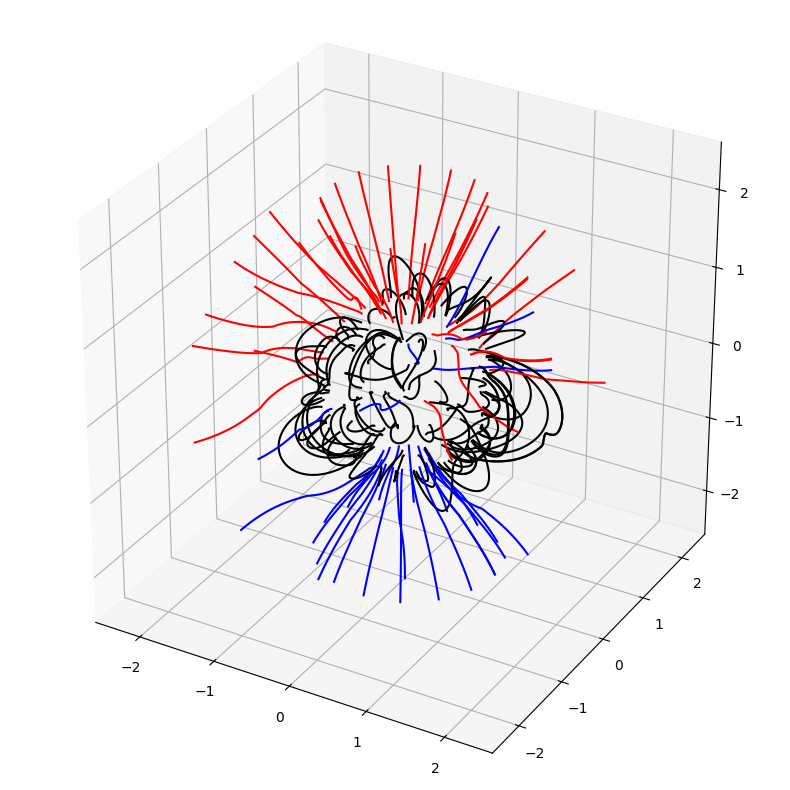

In [ ]:
plotbound = 2.5
fig = plt.figure(figsize = [10, 10])
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim(-plotbound, plotbound)
ax.set_ylim(-plotbound, plotbound)
ax.set_zlim(-plotbound, plotbound)
ax.set_box_aspect([1, 1, 1])
#ax.axis('off')

lines_ud = [lines_full]
for l in range(len(lines_ud)):
    lines = lines_ud[l]
    for i in np.arange(len(lines)):

        line = lines[i]
        polarity = lines_full_openess[i]
        color = {-1: "blue", 0:"black", 1: "red"}[polarity]
        line_r, line_phi, line_theta = line[:, 0], line[:, 1], line[:, 2]

        x = line_r*np.sin(line_theta)*np.cos(line_phi)
        y = line_r*np.sin(line_theta)*np.sin(line_phi)
        z = line_r*np.cos(line_theta)
        

        #plt.plot(tracer.xs[i][:, 0], tracer.xs[i][:, 1], tracer.xs[i][:, 2])
        ax.plot(x, y, z, c = color, ls = '-', linewidth = 1.5, zorder = 5)
plt.show()


# Package logo

In [63]:
nsteps = 20
rval = 1.2

Nlines_v, Nlines_h = nsteps + 1, 2

center = 289
lon1, lon2, offset = center - 90, center + 90 - 360, 90 / nsteps

lon_1d = np.linspace(lon1, lon2, Nlines_h)
lat_1d = np.linspace(-90 + offset, 90 - offset, Nlines_v)

lon, lat = np.meshgrid(lon_1d, lat_1d, indexing='ij')
lon, lat = lon*u.deg, lat*u.deg
lon, lat = lon.ravel(), lat.ravel()

In [64]:
seeds_full = np.ones((Nlines_h*Nlines_v, 3))
seeds_full[:, 0], seeds_full[:, 1], seeds_full[:, 2] = rval, lon.to(u.rad).value, np.pi/2 - lat.to(u.rad).value

tracer.trace(seeds_full, vector_grid_full)
lines_full = []
lines_full_start = []
lines_full_openess = []
for i in np.arange(len(seeds_full)):
    line = tracer.xs[i]
    openess = np.sign(int(abs(line[0, 0] - line[-1, 0])))
    length = len(line)
    lines_full.append(line)
    lines_full_openess.append(openess)
    
    lines_full_start.append(line[0])
lines_full_start = np.array(lines_full_start)
start_r, start_t, start_p = lines_full_start[:, 0], lines_full_start[:, 2], lines_full_start[:, 1]

Br_start = interpolate.interpn(( r, p_coord, t_coord), Brc, (start_r, start_p, start_t))
sign_start = np.sign(Br_start)
lines_full_openess = np.array(lines_full_openess)*sign_start

In [13]:
from matplotlib.patches import Ellipse, PathPatch
from matplotlib.path import Path
import matplotlib.patches as patches




[11.25  5.  ]


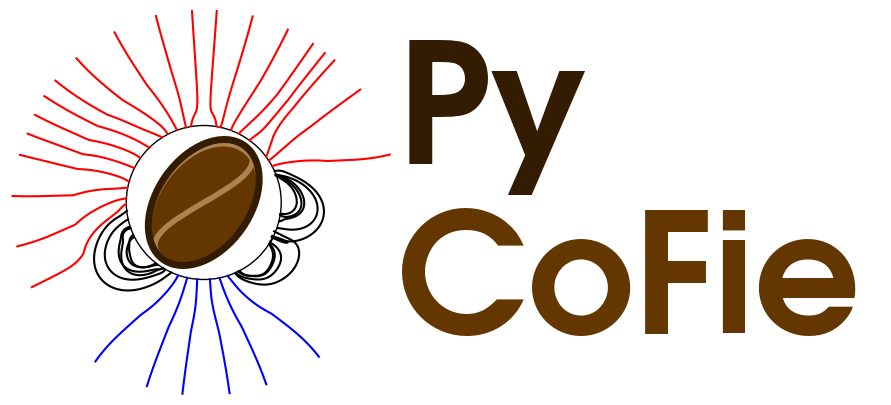

In [65]:
plotbound = 2.5
plotscale = 1
lbound, rbound = -plotbound, 3.5*plotbound
plotdimension = np.array([rbound-lbound, 2*plotbound])*plotscale
print(plotdimension)
fig = plt.figure(figsize = plotdimension)
ax = fig.add_subplot(111)#, projection='3d')

ax.set_xlim(lbound, rbound)
ax.set_ylim(-plotbound, plotbound)
#ax.set_zlim(-plotbound, plotbound)
ax.axis('off')

lines_ud = [lines_full]
for l in range(len(lines_ud)):
    lines = lines_ud[l]
    for i in np.arange(len(lines)):

        line = lines[i]
        polarity = lines_full_openess[i]
        color = {-1: "blue", 0:"black", 1: "red"}[polarity]
        line_r, line_phi, line_theta = line[:, 0], line[:, 1], line[:, 2]

        x = line_r*np.sin(line_theta)*np.cos(line_phi - np.radians(center))
        y = line_r*np.sin(line_theta)*np.sin(line_phi - np.radians(center))
        z = line_r*np.cos(line_theta)
        

        #plt.plot(tracer.xs[i][:, 0], tracer.xs[i][:, 1], tracer.xs[i][:, 2])
        ax.plot(y, z, c = color, ls = '-', linewidth = 1.5, zorder = 5)

################################
beanw, beanh = 1.5 * 0.8, 2.5 * 0.725
lw_scale = 5
angle = -35
edgecolor = 'xkcd:dark brown'
facecolor = 'xkcd:light brown'
shadecolor = 'xkcd:brown'

bean = patches.Ellipse((0, 0), width=beanw, height=beanh, angle=angle,
                        transform=ax.transData, edgecolor='none', linewidth=lw_scale, facecolor=facecolor)
beanedge = patches.Ellipse((0, 0), width=beanw, height=beanh, angle=angle,
                        transform=ax.transData, edgecolor=edgecolor, linewidth=lw_scale, facecolor='none')

# Triple twist seam
verts = [(0.5, beanh/2*0.825),   # start
        (1.2, 0.25),   # control point 1
        (-1.2, -0.25),     # control point 2
        (-0.5, -beanh/2*0.825)      # end
        ]
codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
path = Path(verts, codes)
seam = PathPatch(path, edgecolor=facecolor, facecolor='none', linewidth=lw_scale*.8)

shade = patches.Ellipse(
    (0.0, -0.05),
    width=beanw*0.95,
    height=beanh*0.95,
    angle=angle,
    facecolor=shadecolor,
    alpha=1
)



circ = patches.Circle((0, 0), radius=1, transform=ax.transData, facecolor='none', edgecolor='k')
for p in [bean, shade, seam, beanedge, circ]:#, highlight]:
    ax.add_patch(p)
    #art3d.pathpatch_2d_to_3d(p, z=-5, zdir="x")
ax.text(2.5, 0.1, 'Py', fontsize=120, 
        fontfamily='URW Gothic',
        fontweight='bold', color='xkcd:dark brown', ha='left', va='bottom')
ax.text(2.5, -0.1, 'CoFie', fontsize=120, 
        fontfamily='URW Gothic',
        fontweight='bold', color='xkcd:brown', ha='left', va='top')

plt.savefig('PyCoFie_logo.png', dpi = 600, bbox_inches = 'tight', pad_inches = 0.1)
plt.savefig('PyCoFie_logo.pdf', dpi = 600, bbox_inches = 'tight', pad_inches = 0.1)
plt.show()

# Compare solution with PFSSpy

In [37]:
import pfsspy 
import pfsspy.utils 
from pfsspy import tracing

In [39]:
nrho = Nr - 1
rss = 2.5
pfss_in = pfsspy.Input(hmi_map_superpix, nrho, rss)
pfss_out = pfsspy.pfss(pfss_in)

In [40]:
print(np.shape(pfss_out.bg), np.shape(Brp))

(361, 181, 51, 3) (51, 361, 181)


/home/chingamfong/.local/lib/python3.12/site-packages/pfsspy/output.py:95: UserWarning: Could not parse unit string "Mx/cm^2" as a valid FITS unit.
See https://fits.gsfc.nasa.gov/fits_standard.html for the FITS unit standards.
  warnings.warn(f'Could not parse unit string "{unit_str}" as a valid FITS unit.\n'


In [41]:
Brpf = pfss_out.bg[:, :, :, 2]
print(np.shape(Brpf))
Brpf = Brpf.transpose(2, 0, 1)
print(np.shape(Brpf))


(361, 181, 51)
(51, 361, 181)


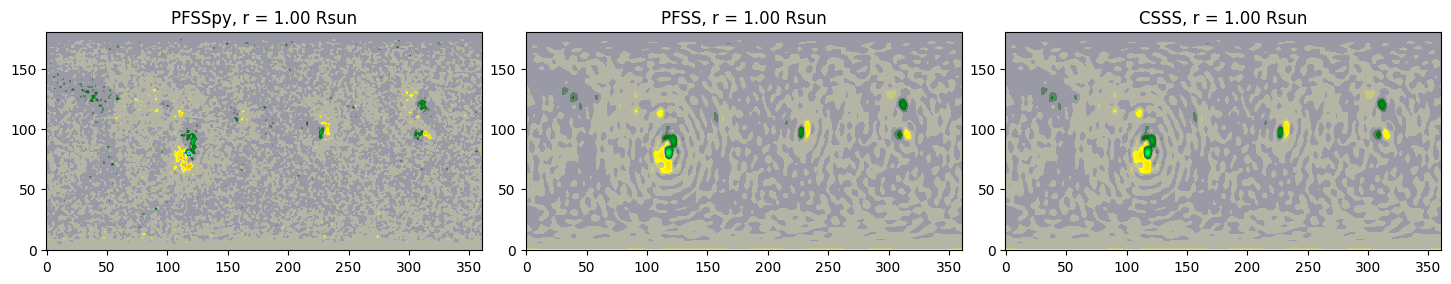

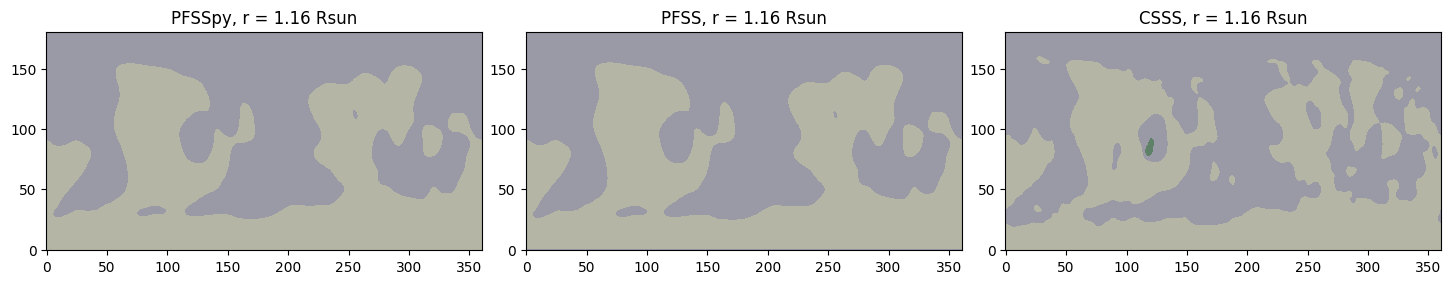

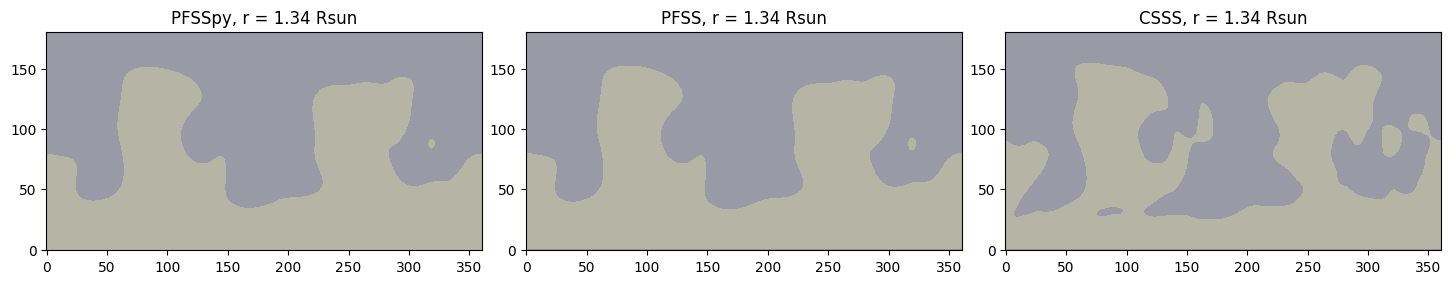

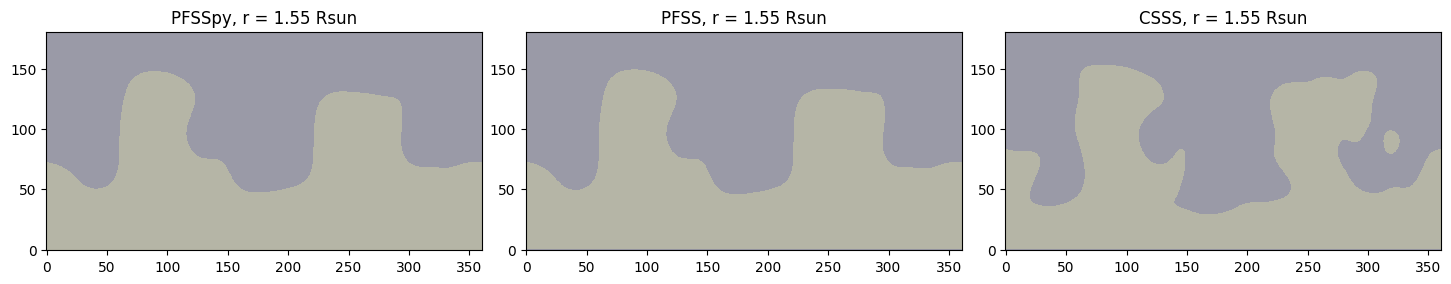

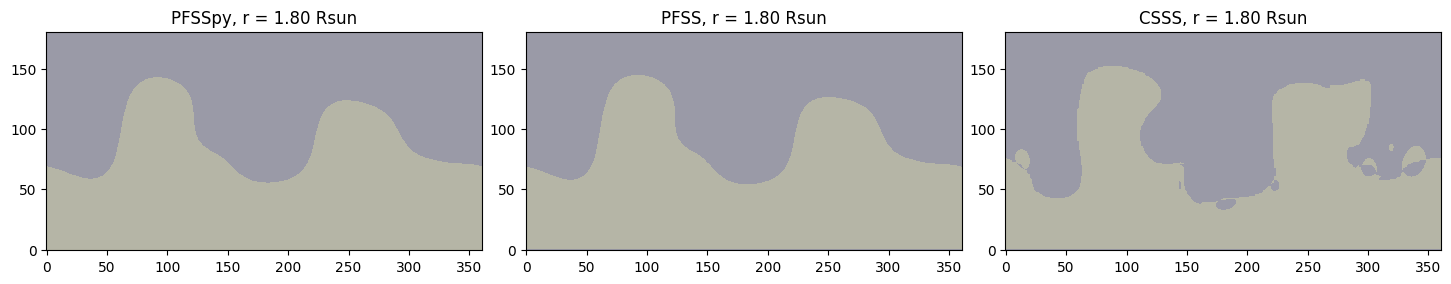

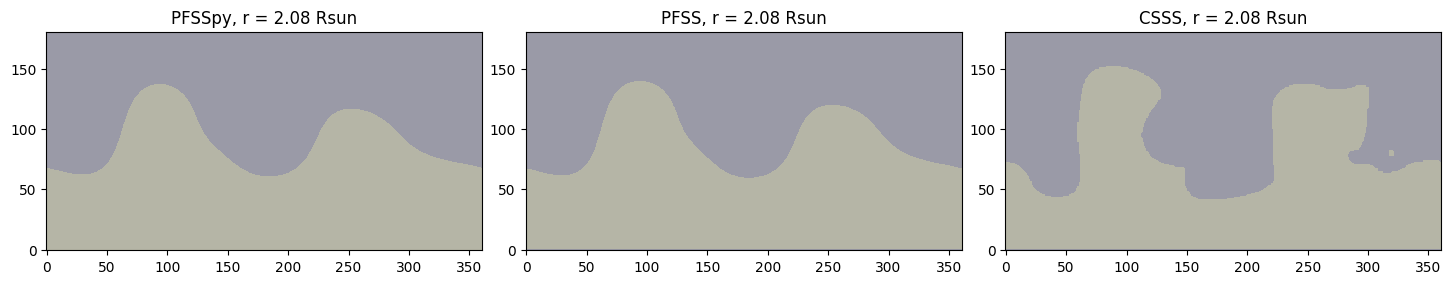

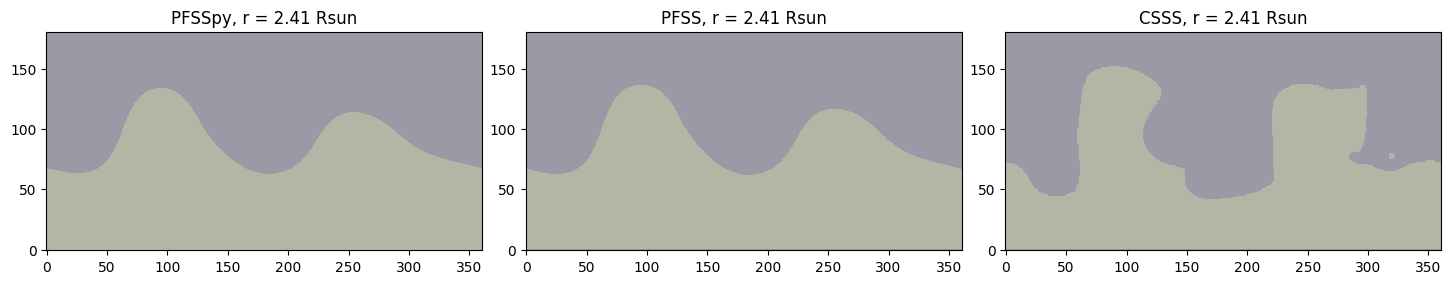

In [49]:
titles = ['PFSSpy', 'PFSS', 'CSSS']
for i in range(len(r))[::8]:
    plt.figure(figsize = [18, 6])
    plt.subplots_adjust(wspace = 0.1)
    for j, Br in enumerate([Brpf, Brp, Brc]):
    
        plt.subplot(1, 3, j+1)
        plt.title(f'{titles[j]}, r = {r[i]:.2f} Rsun')
        plt.imshow(Br[i, :, :].T, origin = 'lower', vmin = -1500, vmax = 1500, cmap = 'hmimag')
    plt.show()